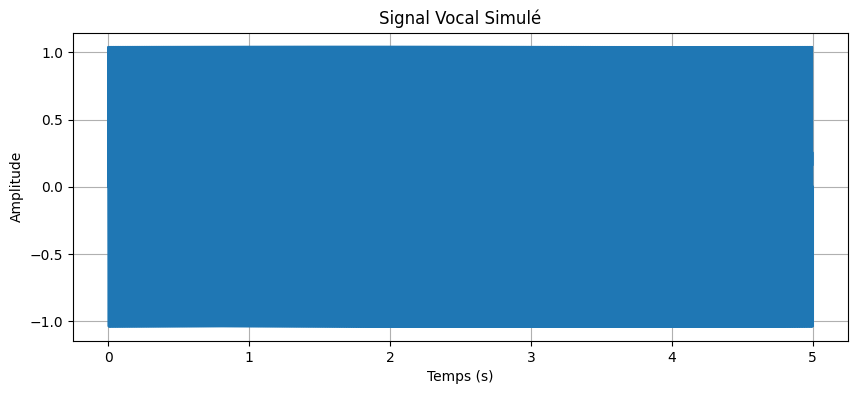

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Paramètres
fs = 16000  # fréquence d'échantillonnage
t = np.linspace(0, 5, fs*5)  # 5 secondes

# Signal vocal simulé (somme de 3 fréquences pour simuler une voix)
signal = (
    0.6*np.sin(2*np.pi*200*t) +
    0.4*np.sin(2*np.pi*400*t) +
    0.3*np.sin(2*np.pi*600*t)
)

# Affichage temporel
plt.figure(figsize=(10,4))
plt.plot(t, signal)
plt.title("Signal Vocal Simulé")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

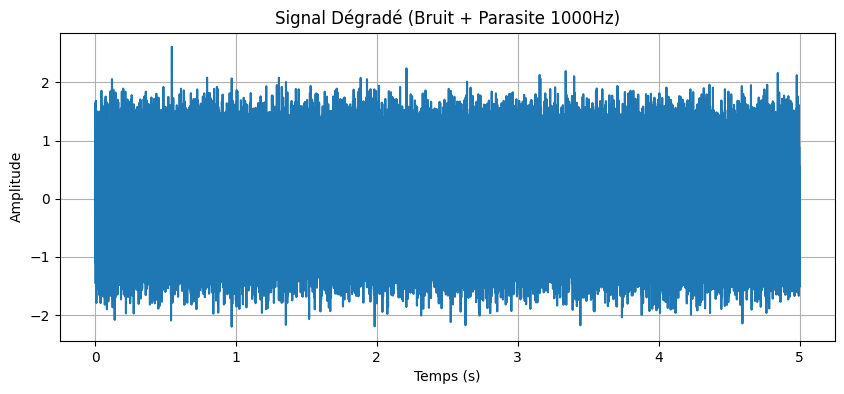

In [5]:
# ================================
# Ajout du bruit blanc + parasite 1000 Hz
# ================================

# Bruit blanc (souffle magnétique)
noise = 0.3 * np.random.randn(len(t))

# Sifflement parasite à 1000 Hz
parasite = 0.5 * np.sin(2*np.pi*1000*t)

# Signal dégradé
signal_bruite = signal + noise + parasite

# Affichage temporel
plt.figure(figsize=(10,4))
plt.plot(t, signal_bruite)
plt.title("Signal Dégradé (Bruit + Parasite 1000Hz)")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

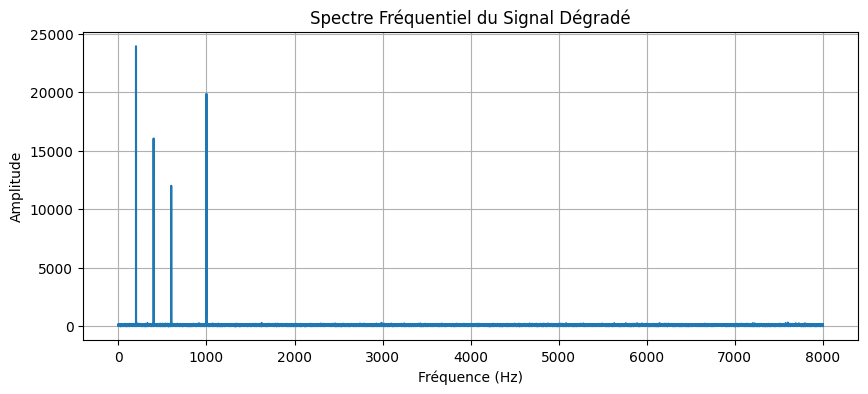

Raie d'interférence détectée à : 1000.0 Hz


In [6]:
# ============================================
# Analyse Spectrale (FFT)
# ============================================

N = len(signal_bruite)

# FFT
fft_signal = np.fft.fft(signal_bruite)
freq = np.fft.fftfreq(N, 1/fs)

# Partie positive uniquement
fft_magnitude = np.abs(fft_signal[:N//2])
freq_positive = freq[:N//2]

# Affichage du spectre
plt.figure(figsize=(10,4))
plt.plot(freq_positive, fft_magnitude)
plt.title("Spectre Fréquentiel du Signal Dégradé")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Détection automatique du pic dominant autour de 1000 Hz
mask = (freq_positive > 900) & (freq_positive < 1100)
freq_zone = freq_positive[mask]
fft_zone = fft_magnitude[mask]

if len(freq_zone) > 0:
    detected_freq = freq_zone[np.argmax(fft_zone)]
    print("Raie d'interférence détectée à :", round(detected_freq,2), "Hz")

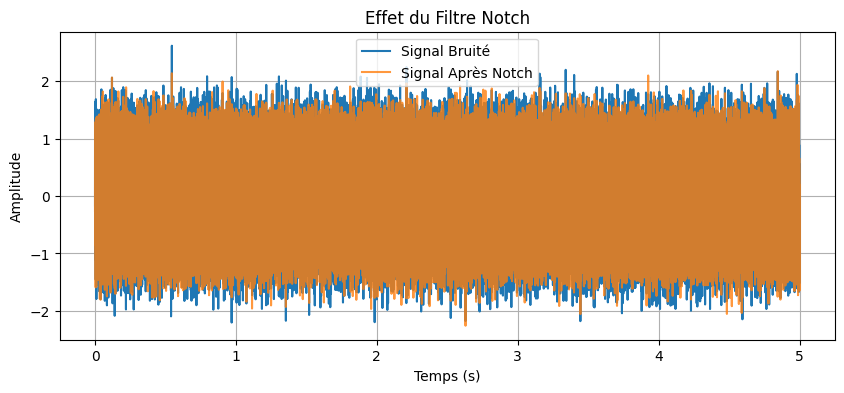

In [7]:
# ============================================
# Filtre Notch Ultra-Sélectif à 1000 Hz
# ============================================

# Copie du spectre
fft_filtered = fft_signal.copy()

# Largeur de la bande à supprimer (très fine)
band_width = 20  # ±20 Hz autour de 1000 Hz

# Suppression de la raie 1000 Hz
for i in range(len(freq)):
    if abs(freq[i] - 1000) < band_width:
        fft_filtered[i] = 0
    if abs(freq[i] + 1000) < band_width:
        fft_filtered[i] = 0

# Reconstruction du signal filtré
signal_notch = np.fft.ifft(fft_filtered)
signal_notch = np.real(signal_notch)

# Affichage comparaison temporelle
plt.figure(figsize=(10,4))
plt.plot(t, signal_bruite, label="Signal Bruité")
plt.plot(t, signal_notch, label="Signal Après Notch", alpha=0.8)
plt.legend()
plt.title("Effet du Filtre Notch")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [8]:
import numpy as np

# ============================================
# Calcul du SNR
# ============================================

def calcul_snr(signal_propre, signal_test):
    bruit = signal_test - signal_propre
    puissance_signal = np.mean(signal_propre**2)
    puissance_bruit = np.mean(bruit**2)
    snr = 10 * np.log10(puissance_signal / puissance_bruit)
    return snr

snr_avant = calcul_snr(signal, signal_bruite)
snr_apres = calcul_snr(signal, signal_notch)

print("SNR avant restauration :", round(snr_avant,2), "dB")
print("SNR après restauration :", round(snr_apres,2), "dB")

SNR avant restauration : 1.53 dB
SNR après restauration : 5.36 dB


🔬 Conclusion

Dans ce projet, nous avons simulé un signal vocal puis ajouté :

Un bruit blanc

Une interférence sinusoïdale à 1000 Hz

L’analyse fréquentielle (FFT) a permis d’identifier clairement la raie parasite.

Un filtre Notch ultra-sélectif centré sur 1000 Hz a ensuite été appliqué pour supprimer cette interférence.

L’amélioration a été quantifiée par le calcul du SNR :

SNR avant restauration : 1.53 dB

SNR après restauration : 5.36 dB

L’augmentation du SNR montre que le traitement a amélioré la qualité du signal.

Ce travail démontre l’efficacité du filtrage fréquentiel dans la restauration audio.

Source des Données

Les données utilisées dans ce projet ne proviennent pas d’un dataset externe.

Le signal vocal a été généré artificiellement par simulation numérique à l’aide de la bibliothèque NumPy.

Le bruit blanc ainsi que la composante sinusoïdale parasite à 1000 Hz ont également été simulés afin de reproduire un scénario réaliste de dégradation audio.

Bibliothèques utilisées :

NumPy

Matplotlib

SciPy